# Haplotype painting

The signature deliverable: a **soft, calibrated** posterior over ancestry at every position of
every query haplotype. We simulate an admixed sample with known local ancestry, paint it with
[`tslai.paint`](../api/paint.html), and visualise the result against the truth.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import tslai
from tslai.sim import SOURCE_A, SOURCE_B, ADMIXED

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False})

def admixture(n_admix=8, n_ref=8, L=2e6, T_admix=100, Ne=1000, T_split=5000, f_A=0.5,
              seed=1, infer=False, mutation_rate=4e-7):
    """Simulate admixture with known truth; return (ts, labels, queries, truth_states)."""
    ts = tslai.simulate_admixture(n_admix=n_admix, n_ref=n_ref, sequence_length=L,
                                  recombination_rate=1e-8, random_seed=seed, Ne=Ne,
                                  T_admix=T_admix, T_split=T_split, f_A=f_A)
    pop = ts.tables.nodes.population
    name = {p: ts.population(p).metadata.get("name", str(p)) for p in range(ts.num_populations)}
    A = next(p for p, n in name.items() if n == SOURCE_A)
    B = next(p for p, n in name.items() if n == SOURCE_B)
    admix = next(p for p, n in name.items() if n == ADMIXED)
    sop = {A: 0, B: 1}
    labels = {int(s): sop[pop[s]] for s in ts.samples() if pop[s] in (A, B)}
    queries = [int(s) for s in ts.samples() if pop[s] == admix]
    truth = tslai.metrics.map_truth({q: tslai.local_ancestry_truth(ts)[0][q] for q in queries}, sop)
    work = ts
    if infer:
        work = tslai.io.infer_tree_sequence(tslai.io.add_mutations(ts, rate=mutation_rate,
                                                                   random_seed=seed))
    return work, labels, queries, truth

CMAP = "RdBu_r"   # red = ancestry A (state 0), blue = ancestry B (state 1)

def plot_painting(painting, truth, ts, title="", segments=None):
    """Soft posterior P(A) painted along the genome per query haplotype, with a thin truth
    strip beneath each. If `segments` (hard tracts) is given, draw those instead of soft."""
    qs = painting.queries
    L = ts.sequence_length
    sm = cm.ScalarMappable(norm=colors.Normalize(0, 1), cmap=CMAP)
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(qs) + 1.2))
    for i, q in enumerate(qs):
        if segments is None:
            for seg in painting.posteriors[q]:
                ax.barh(i, seg.right - seg.left, left=seg.left, height=0.74,
                        color=sm.to_rgba(seg.posterior[0]), edgecolor="none")
        else:
            for (l, r, s) in segments[q]:
                ax.barh(i, r - l, left=l, height=0.74,
                        color=sm.to_rgba(1.0 if s == 0 else 0.0), edgecolor="none")
        for (l, r, s) in truth[q]:
            ax.barh(i - 0.46, r - l, left=l, height=0.13,
                    color=sm.to_rgba(1.0 if s == 0 else 0.0), edgecolor="none")
    ax.set_xlim(0, L); ax.set_ylim(-0.8, len(qs) - 0.2)
    ax.set_yticks(range(len(qs))); ax.set_yticklabels([f"hap {q}" for q in qs], fontsize=8)
    ax.set_xlabel("genomic position (bp)"); ax.set_title(title)
    cb = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.01)
    cb.set_label("P(ancestry A)")
    ax.text(0, len(qs) - 0.5, "thin strip below each = true ancestry", fontsize=7, color="0.4")
    fig.tight_layout()
    return fig

## Simulate and paint

Recent admixture (long tracts), strong structure so the genealogy discriminates sharply.

In [2]:
ts, labels, queries, truth = admixture(n_admix=8, n_ref=8, L=2e6, T_admix=60, seed=1)
painting = tslai.paint(ts, labels)
painting

Painting(queries=16, K=2, Q=[[-4.19e-05  4.19e-05]
 [ 3.14e-05 -3.14e-05]], pi=[0.5 0.5])

## The painting

Each row is a query haplotype; colour is the posterior probability of ancestry **A** (red) vs **B** (blue), white where the tree cannot tell. The thin strip beneath each row is the true ancestry.

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_75665/1235744173.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


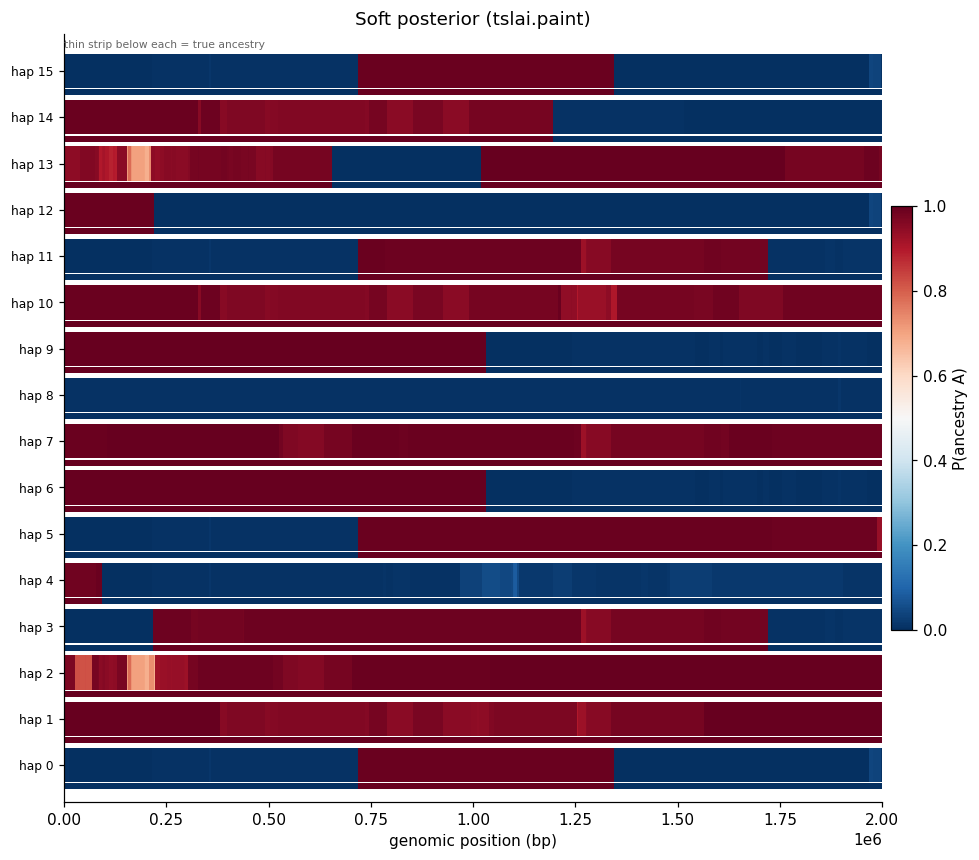

In [3]:
#| label: fig-painting
#| fig-cap: "Soft local-ancestry posterior along each query haplotype (red = ancestry A, blue = B), with true ancestry as the thin strip beneath each row."
fig = plot_painting(painting, truth, ts, "Soft posterior (tslai.paint)")
fig.show()

## Hard tracts for downstream analysis

Collapse the soft posterior to hard ancestry tracts with a confidence **deadband** (suppresses low-confidence flips that fragment long tracts — see the [fragmentation notebook](fragmentation.ipynb)).

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_75665/3025390174.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


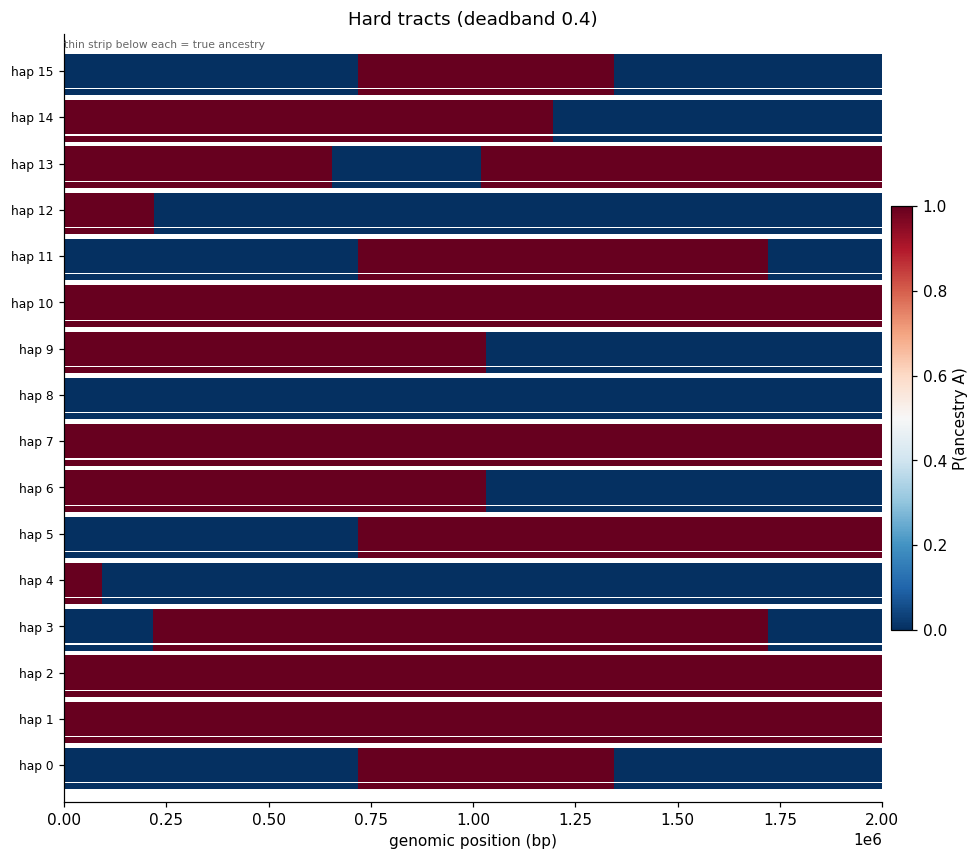

In [4]:
#| label: fig-painting-hard
#| fig-cap: "Hard ancestry tracts from the same posterior (deadband 0.4), matching the true tract structure."
fig = plot_painting(painting, truth, ts, "Hard tracts (deadband 0.4)", segments=painting.segments(deadband=0.4))
fig.show()

## Accuracy

Balanced accuracy and mean confidence of the soft painting.

In [5]:
ba = tslai.metrics.balanced_accuracy(painting.posteriors, truth, samples=queries)
conf = tslai.metrics.mean_confidence(painting.posteriors, samples=queries)
print(f"balanced accuracy = {ba:.3f}   mean confidence = {conf:.3f}")

balanced accuracy = 1.000   mean confidence = 0.976
